In [3]:
from nemo.collections.asr.parts.submodules.wfst_decoder import RivaGpuWfstDecoder
from inference_funcs import load_bit_phoneme_model, load_gru, evaluate_model
from dataset import getDatasetLoaders
import numpy as np
import torch
import torch.nn.functional as F

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
load_predictions = True

device = 'cuda'

model_filepath = "/data/models/time_masked_transfomer_characters_phonemes_80ms_seed_0/"
gru = False

if load_predictions:
    
    logits_torch_arranged = torch.load(f"{model_filepath}logits_arranged.pth").to(dtype=torch.float32, device=device)
    log_probs_arranged = torch.load(f"{model_filepath}log_probs_arranged.pth").to(dtype=torch.float32, device=device)
    log_probs_length = torch.load(f"{model_filepath}log_probs_length.pth").to(dtype=torch.int64, device='cpu')

else: 
    
    if gru:
        model, args = load_gru(model_filepath)
        
    else:    
        model, args = load_bit_phoneme_model(model_filepath)
        
    model = model.to(device)

    data_file = '/data/neural_data/ptDecoder_ctc_both_char_phoneme'
    trainLoaders, testLoaders, loadedData = getDatasetLoaders(
            data_file, 8, None, 
            False
        )

    outputs, cer, per_day_cer, _, _ = evaluate_model(model, loadedData, args, partition='test', device='cuda', verbose=False)

    num_classes = 41
    if gru:
        add_length = 1
    else:
        add_length = 0

    logits = np.zeros((len(outputs['logits2']), max(outputs['logitLengths2'])+add_length, num_classes))
    for idx, l in enumerate(outputs['logits2']):
        l_length = outputs['logitLengths2'][idx]
        if gru:
            l_length += add_length
        logits[idx, :l_length, :] = l
        
    logits_torch = torch.from_numpy(logits)
    logits_torch_blank_last = torch.concat((logits_torch[:, :, 1:], logits_torch[:, :, 0:1]), dim=-1) # move blank to end
    logits_torch_arranged = torch.concat((logits_torch_blank_last[:, :, -1:], logits_torch_blank_last[:, :, -2:-1], logits_torch_blank_last[:, :, :-2]), dim=-1)
    
    log_probs_arranged = F.log_softmax(logits_torch_arranged, dim=-1).to(dtype=torch.float32, device=device)
    log_probs_length = torch.from_numpy(np.array(outputs['logitLengths2'])).to(dtype=torch.int64, device='cpu')

    torch.save(logits_torch_arranged, f"{model_filepath}/logits_arranged.pth")
    torch.save(log_probs_arranged, f"{model_filepath}log_probs_arranged.pth")
    torch.save(log_probs_length, f"{model_filepath}log_probs_length.pth")


In [8]:
language_model_fst_path = "/data/code/nejm-brain-to-text/language_model/pretrained_language_models/openwebtext_1gram_lm_sil/TLG_with_symbols.fst"
language_model_path_3g = '/data/lm/TLG_opt_with_symbols.fst'

max_mem = 50000000
blank_penalty = 0.7
lm_weight = 1
beam_size = 300
nbest_size = 300
batch_size = 1
acoustic_scale = 10

decoder = RivaGpuWfstDecoder(lm_fst=language_model_fst_path, decoding_mode="nbest", 
                             beam_size=beam_size, lm_weight=lm_weight,
                             nbest_size=nbest_size, max_mem=max_mem, blank_penalty=blank_penalty, 
                             max_batch_size = batch_size, acoustic_scale = acoustic_scale)

In [9]:
import pickle
with open('/data/text/validation_sentences_ground_truth.pkl', 'rb') as f:
    val_ground_truth_all = pickle.load(f)

In [10]:
log_probs_arranged.shape

torch.Size([880, 230, 41])

In [11]:
T = 1.1
idx = 50
log_probs_arranged = F.log_softmax(logits_torch_arranged/T, dim=-1).to(dtype=torch.float32, device=device)

log_probs_one_sample = torch.unsqueeze(log_probs_arranged[idx], dim=0)
log_probs_length_one_sample = torch.unsqueeze(log_probs_length[idx], dim=0)
print(log_probs_length_one_sample)

max_len = None
if max_len is not None:
    log_probs_one_sample = log_probs_one_sample[:, 0:max_len, :]
    log_probs_length_one_sample[0] = max_len
    
print(val_ground_truth_all[idx])

tensor([113])
shaving cream is a popular item on halloween


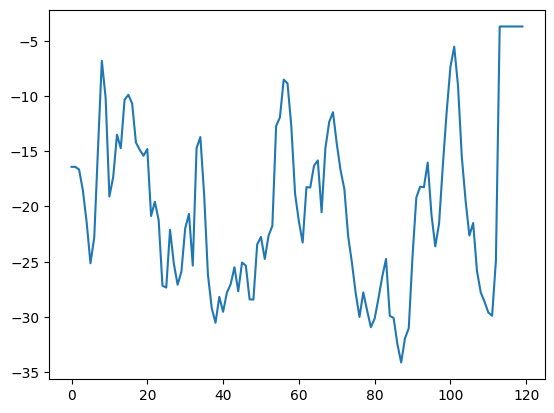

In [21]:
from matplotlib import pyplot as plt
plt.plot(log_probs_one_sample[0, :120, -1].cpu())

In [82]:
hypotheses = decoder._decode_nbest(log_probs_one_sample, log_probs_length_one_sample)

LOG ([5.5]:RebuildRepository():lat/determinize-lattice-pruned.cc:287) Rebuilding repository.
LOG ([5.5]:RebuildRepository():lat/determinize-lattice-pruned.cc:287) Rebuilding repository.
LOG ([5.5]:RebuildRepository():lat/determinize-lattice-pruned.cc:287) Rebuilding repository.
WARNING ([5.5]:CheckMemoryUsage():lat/determinize-lattice-pruned.cc:320) Did not reach requested beam in determinize-lattice: size exceeds maximum 50000000 bytes; (repo,arcs,elems) = (29911968,3985824,16216536), after rebuilding, repo size was 27130688, effective beam was 50.1748 vs. requested beam 300
LOG ([5.5]:DeterminizeLatticePruned():lat/determinize-lattice-pruned.cc:1235) Pruned state-level lattice with beam 150 and retrying determinization with that beam.
LOG ([5.5]:RebuildRepository():lat/determinize-lattice-pruned.cc:287) Rebuilding repository.
LOG ([5.5]:RebuildRepository():lat/determinize-lattice-pruned.cc:287) Rebuilding repository.
LOG ([5.5]:RebuildRepository():lat/determinize-lattice-pruned.cc:28

In [83]:
for i in range(300):
    print(hypotheses[0]._hypotheses[i].words)

('SAVE', 'CAME', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'HOLLERN')
('SAVE', 'KAIM', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'HOLLERN')
('SAVE', 'CAME', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'HULEN')
('SAVE', 'KAIM', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'HULEN')
('SAVE', 'CAME', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'ALLIN')
('SAVE', 'KAIM', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'ALLIN')
('SAVE', 'CAME', 'IS', 'UHH', 'PROPERLY', 'TIME', 'ON', 'HOLLERN')
('SAVE', 'KAIM', 'IS', 'UHH', 'PROPERLY', 'TIME', 'ON', 'HOLLERN')
('SAVE', 'CAME', 'IS', 'UH', 'PROPERLY', 'TIME', 'ON', 'HOLLERN')
('SAVE', 'KAIM', 'IS', 'UH', 'PROPERLY', 'TIME', 'ON', 'HOLLERN')
('SAVE', 'KEIM', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'HOLLERN')
('SAVE', 'CAME', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'ALEEN')
('SAVE', 'KAIM', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'ALEEN')
('SAVE', 'CAME', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'ALENE')
('SAVE', 'KAIM', 'IS', 'A', 'PROPERLY', 'TIME', 'ON', 'ALENE')
('SAVE', 'CAME', 'IS', 'UH', 'PROPE